In [ ]:
# Install gdown for downloading files from Google Drive
!pip install -qqq gdown

# Download the dataset from the provided Google Drive link
!gdown --id 1XHYliYyNUyqEK3vkoQtu1wHMd46zpIdo -O public_reviews_dataset_cleaned

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1XHYliYyNUyqEK3vkoQtu1wHMd46zpIdo
From (redirected): https://drive.google.com/uc?id=1XHYliYyNUyqEK3vkoQtu1wHMd46zpIdo&confirm=t&uuid=bb6a51c0-2071-4a51-a6d7-fa14c0142b68
To: /content/public_reviews_dataset_cleaned
100% 280M/280M [00:02<00:00, 112MB/s]


In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('public_reviews_dataset_cleaned')

print('Original DataFrame head:')
display(df.head())

/tmp/ipykernel_822/3125398511.py:5: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('public_reviews_dataset_cleaned')


Original DataFrame head:


,asin,review_id,reviewer_id,review_title,review_text,review_rating,review_date,product_title,product_url,number_of_helpful,...,asin_url,review_url,reviewer_url,fake_review_campaign_start_date,fake_review_product,reviewer_classified_fake,reviewer_classified_honest,reviewer_labeled_fake,reviewer_labeled_honest,review_is_removed_by_amazon
0,B003MROHZW,R2RDK8SL1QXN8I,AHAHNBDF4GJ26DAL3VS7MGJDNCKA,Dog muzzle,Serves it purpose.,5,2016-01-22,Downtown Pet Supply Quick Fit Dog Muzzle with ...,https://www.amazon.com/Small-Muzzle-Downtown-P...,0.0,...,https://www.amazon.com/dp/B003MROHZW,https://www.amazon.com/gp/customer-reviews/R2R...,https://www.amazon.com/gp/profile/amzn1.accoun...,2020-02-08,True,True,False,0.0,0.0,0.0
1,B008DZ6JPO,R1CSQAGJT0JXO7,AEZ2DKBYDRPE5O3ENPHV3XRJBMGQ,Awesome product!!,I use this ALL the time!! Looks really nice ...,5,2017-09-25,Winsome 92436 Luggage Rack with Shelf,https://www.amazon.com/Winsome-92436-Luggage-R...,0.0,...,https://www.amazon.com/dp/B008DZ6JPO,https://www.amazon.com/gp/customer-reviews/R1C...,https://www.amazon.com/gp/profile/amzn1.accoun...,NaN,True,True,False,0.0,0.0,0.0
2,B008DZ6JPO,R1XD30XZ3BXO7F,AF52D4YPSCPGLWNYVXZDGG525R2A,Good quality. Color is nice just like the pict...,Well made product. I purchased that refurbishe...,5,2018-11-14,Winsome 92436 Luggage Rack with Shelf,https://www.amazon.com/Winsome-92436-Luggage-R...,0.0,...,https://www.amazon.com/dp/B008DZ6JPO,https://www.amazon.com/gp/customer-reviews/R1X...,https://www.amazon.com/gp/profile/amzn1.accoun...,NaN,True,True,False,0.0,0.0,0.0
3,B008DZ6JPO,R3L61UVBYHB2QK,AFPXQX5HARB76E7GOIUTU32332KQ,Nice Looking and Easy Set Up,"Nice looking, sturdy and easy to set up.",5,2020-02-04,Winsome 92436 Luggage Rack with Shelf,https://www.amazon.com/Winsome-92436-Luggage-R...,0.0,...,https://www.amazon.com/dp/B008DZ6JPO,https://www.amazon.com/gp/customer-reviews/R3L...,https://www.amazon.com/gp/profile/amzn1.accoun...,NaN,True,True,False,0.0,0.0,0.0
4,B00GIHF6AS,R36G7QSYO7QRAS,AFP3AD7L3KWYHHQ4UQAIWJAZX7FQ,Cut pvc like fruit.,", Your browser does not support HTML5 video...",5,2020-03-10,"MAXPOWER Automatic PVC Pipe Cutter, Ratchet-ty...",https://www.amazon.com/MAXPOWER-Cortatubos-aut...,4.0,...,https://www.amazon.com/dp/B00GIHF6AS,https://www.amazon.com/gp/customer-reviews/R36...,https://www.amazon.com/gp/profile/amzn1.accoun...,2020-02-14,True,True,False,1.0,0.0,0.0


In [ ]:
# Initialize 'tag' column with NaN to easily identify rows that don't fit any category
df['tag'] = np.nan

# Condition for fake reviews (tag = 0.0)
fake_condition = (df['reviewer_classified_fake'] == True) | (df['reviewer_labeled_fake'] == True)
df.loc[fake_condition, 'tag'] = 0.0

# Condition for honest reviews (tag = 1.0)
honest_condition = (df['reviewer_classified_honest'] == True) | (df['reviewer_labeled_honest'] == True)
df.loc[honest_condition, 'tag'] = 1.0

# Filter out rows where 'tag' is still NaN (i.e., didn't fit into fake or honest)
df_filtered = df.dropna(subset=['tag']).copy()

# Convert 'tag' column to integer type for clarity, as it's 0.0 or 1.0
df_filtered['tag'] = df_filtered['tag'].astype(int)

print('DataFrame head after creating and filtering by the new "tag" column:')
display(df_filtered.head())

DataFrame head after creating and filtering by the new "tag" column:


,asin,review_id,reviewer_id,review_title,review_text,review_rating,review_date,product_title,product_url,number_of_helpful,...,review_url,reviewer_url,fake_review_campaign_start_date,fake_review_product,reviewer_classified_fake,reviewer_classified_honest,reviewer_labeled_fake,reviewer_labeled_honest,review_is_removed_by_amazon,tag
0,B003MROHZW,R2RDK8SL1QXN8I,AHAHNBDF4GJ26DAL3VS7MGJDNCKA,Dog muzzle,Serves it purpose.,5,2016-01-22,Downtown Pet Supply Quick Fit Dog Muzzle with ...,https://www.amazon.com/Small-Muzzle-Downtown-P...,0.0,...,https://www.amazon.com/gp/customer-reviews/R2R...,https://www.amazon.com/gp/profile/amzn1.accoun...,2020-02-08,True,True,False,0.0,0.0,0.0,0
1,B008DZ6JPO,R1CSQAGJT0JXO7,AEZ2DKBYDRPE5O3ENPHV3XRJBMGQ,Awesome product!!,I use this ALL the time!! Looks really nice ...,5,2017-09-25,Winsome 92436 Luggage Rack with Shelf,https://www.amazon.com/Winsome-92436-Luggage-R...,0.0,...,https://www.amazon.com/gp/customer-reviews/R1C...,https://www.amazon.com/gp/profile/amzn1.accoun...,NaN,True,True,False,0.0,0.0,0.0,0
2,B008DZ6JPO,R1XD30XZ3BXO7F,AF52D4YPSCPGLWNYVXZDGG525R2A,Good quality. Color is nice just like the pict...,Well made product. I purchased that refurbishe...,5,2018-11-14,Winsome 92436 Luggage Rack with Shelf,https://www.amazon.com/Winsome-92436-Luggage-R...,0.0,...,https://www.amazon.com/gp/customer-reviews/R1X...,https://www.amazon.com/gp/profile/amzn1.accoun...,NaN,True,True,False,0.0,0.0,0.0,0
3,B008DZ6JPO,R3L61UVBYHB2QK,AFPXQX5HARB76E7GOIUTU32332KQ,Nice Looking and Easy Set Up,"Nice looking, sturdy and easy to set up.",5,2020-02-04,Winsome 92436 Luggage Rack with Shelf,https://www.amazon.com/Winsome-92436-Luggage-R...,0.0,...,https://www.amazon.com/gp/customer-reviews/R3L...,https://www.amazon.com/gp/profile/amzn1.accoun...,NaN,True,True,False,0.0,0.0,0.0,0
4,B00GIHF6AS,R36G7QSYO7QRAS,AFP3AD7L3KWYHHQ4UQAIWJAZX7FQ,Cut pvc like fruit.,", Your browser does not support HTML5 video...",5,2020-03-10,"MAXPOWER Automatic PVC Pipe Cutter, Ratchet-ty...",https://www.amazon.com/MAXPOWER-Cortatubos-aut...,4.0,...,https://www.amazon.com/gp/customer-reviews/R36...,https://www.amazon.com/gp/profile/amzn1.accoun...,2020-02-14,True,True,False,1.0,0.0,0.0,0


In [ ]:
print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape: {df_filtered.shape}")
print(f"Number of rows removed: {df.shape[0] - df_filtered.shape[0]}")

Original DataFrame shape: (381734, 24)
Filtered DataFrame shape: (80281, 24)
Number of rows removed: 301453


In [ ]:
# Select relevant columns and rename 'review_text' to 'text'
df_cleaned = df_filtered[['tag', 'review_text']].copy()
df_cleaned.rename(columns={'review_text': 'text'}, inplace=True)

print('DataFrame after column selection and renaming:')
display(df_cleaned.head())

DataFrame after column selection and renaming:


,tag,text
0,0,Serves it purpose.
1,0,I use this ALL the time!! Looks really nice ...
2,0,Well made product. I purchased that refurbishe...
3,0,"Nice looking, sturdy and easy to set up."
4,0,", Your browser does not support HTML5 video..."


In [ ]:
import re
import unicodedata

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # 1. URL & Email Masking (Your exact logic)
    text = re.sub(r'\S*@\S*\.com|\S*@\S*\.net|\S*@\S*\.org|\S*@\S*\.edu|\S*@\S*\.gov', '<EMAIL>', text)
    text = re.sub(r'https?:\/\/\S+|www\.\S+', '<URL>', text)
    text = re.sub(r'\b[a-zA-Z0-9.-]+\.(?:com|org|net|edu|gov|io|co|us|uk|ca|au|de|jp|fr|cn|in|ru)\b(?:\/\S*)?', '<URL>', text)

    # 2. Whitespace Normalization (DO THIS FIRST to save \n and \t)
    text = re.sub(r'\s+', ' ', text)

    # 3. Control Character Removal (Now it's safe to destroy the remaining invisible C characters)
    text = ''.join(ch for ch in text if unicodedata.category(ch)[0] != 'C')

    return text.strip()


# Apply the cleaning function to the 'text' column
df_cleaned['text'] = df_cleaned['text'].apply(clean_text)

print('DataFrame head after text cleaning:')
display(df_cleaned.head())

DataFrame head after text cleaning:


,tag,text
0,0,Serves it purpose.
1,0,I use this ALL the time!! Looks really nice an...
2,0,Well made product. I purchased that refurbishe...
3,0,"Nice looking, sturdy and easy to set up."
4,0,", Your browser does not support HTML5 video., ..."


In [ ]:
df=df_cleaned

In [ ]:
df.head()

,tag,text
0,0,Serves it purpose.
1,0,I use this ALL the time!! Looks really nice an...
2,0,Well made product. I purchased that refurbishe...
3,0,"Nice looking, sturdy and easy to set up."
4,0,", Your browser does not support HTML5 video., ..."


In [ ]:
print(df['tag'].value_counts())

tag
0    57593
1    22688
Name: count, dtype: int64


✅ Device : cuda
   GPU   : Tesla T4
   VRAM  : 15.6 GB

── 1. Data prep ────────────────────────────────────────


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

  Train:   0%|                         | 0/1004 [00:00<?] loss=


════════════════════════════════════════════════════════════
   EPOCH 1 REPORT  (392s)
════════════════════════════════════════════════════════════
   Train loss : 0.5954   Train acc : 71.98%
   Val loss   : 0.5927
────────────────────────────────────────────────────────────
   Threshold  : 0.74  (best class 0 F1 on val)
   Accuracy   : 78.69%
   AUC-ROC    : 81.28%
────────────────────────────────────────────────────────────
   Metric                Class (0)    Class (1)
   Precision                81.36%       67.73%
   Recall                   91.18%       46.98%
   F1                       85.99%       55.48%
────────────────────────────────────────────────────────────
   F1 Macro   : 70.74%   F1 Weighted: 77.37%
   Prec Macro : 74.54%   Rec Macro  : 69.08%
════════════════════════════════════════════════════════════
   Predicted → class 0: 6,455 | class 1: 1,574  (actual class 0: 5,760)
   ✅ Best model saved  (Class 0 F1 = 85.99%)

Epoch 2/2
─────────────────────────────────────

  Train:   0%|                         | 0/1004 [00:00<?] loss=

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b48169c45e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Exception ignored in: AssertionError<function _MultiProcessingDataLoaderIter.__del__ at 0x7b48169c45e0>: 
can only test a child processTraceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


════════════════════════════════════════════════════════════
   EPOCH 2 REPORT  (392s)
════════════════════════════════════════════════════════════
   Train loss : 0.5304   Train acc : 76.93%
   Val loss   : 0.5815
────────────────────────────────────────────────────────────
   Threshold  : 0.77  (best class 0 F1 on val)
   Accuracy   : 79.19%
   AUC-ROC    : 82.35%
────────────────────────────────────────────────────────────
   Metric                Class (0)    Class (1)
   Precision                81.55%       69.32%
   Recall                   91.75%       47.29%
   F1                       86.35%       56.22%
────────────────────────────────────────────────────────────
   F1 Macro   : 71.29%   F1 Weighted: 77.84%
   Prec Macro : 75.43%   Rec Macro  : 69.52%
════════════════════════════════════════════════════════════
   Predicted → class 0: 6,481 | class 1: 1,548  (actual class 0: 5,760)
   ✅ Best model saved  (Class 0 F1 = 86.35%)

── 8. Final evaluation (best epoch = 2) ────

═

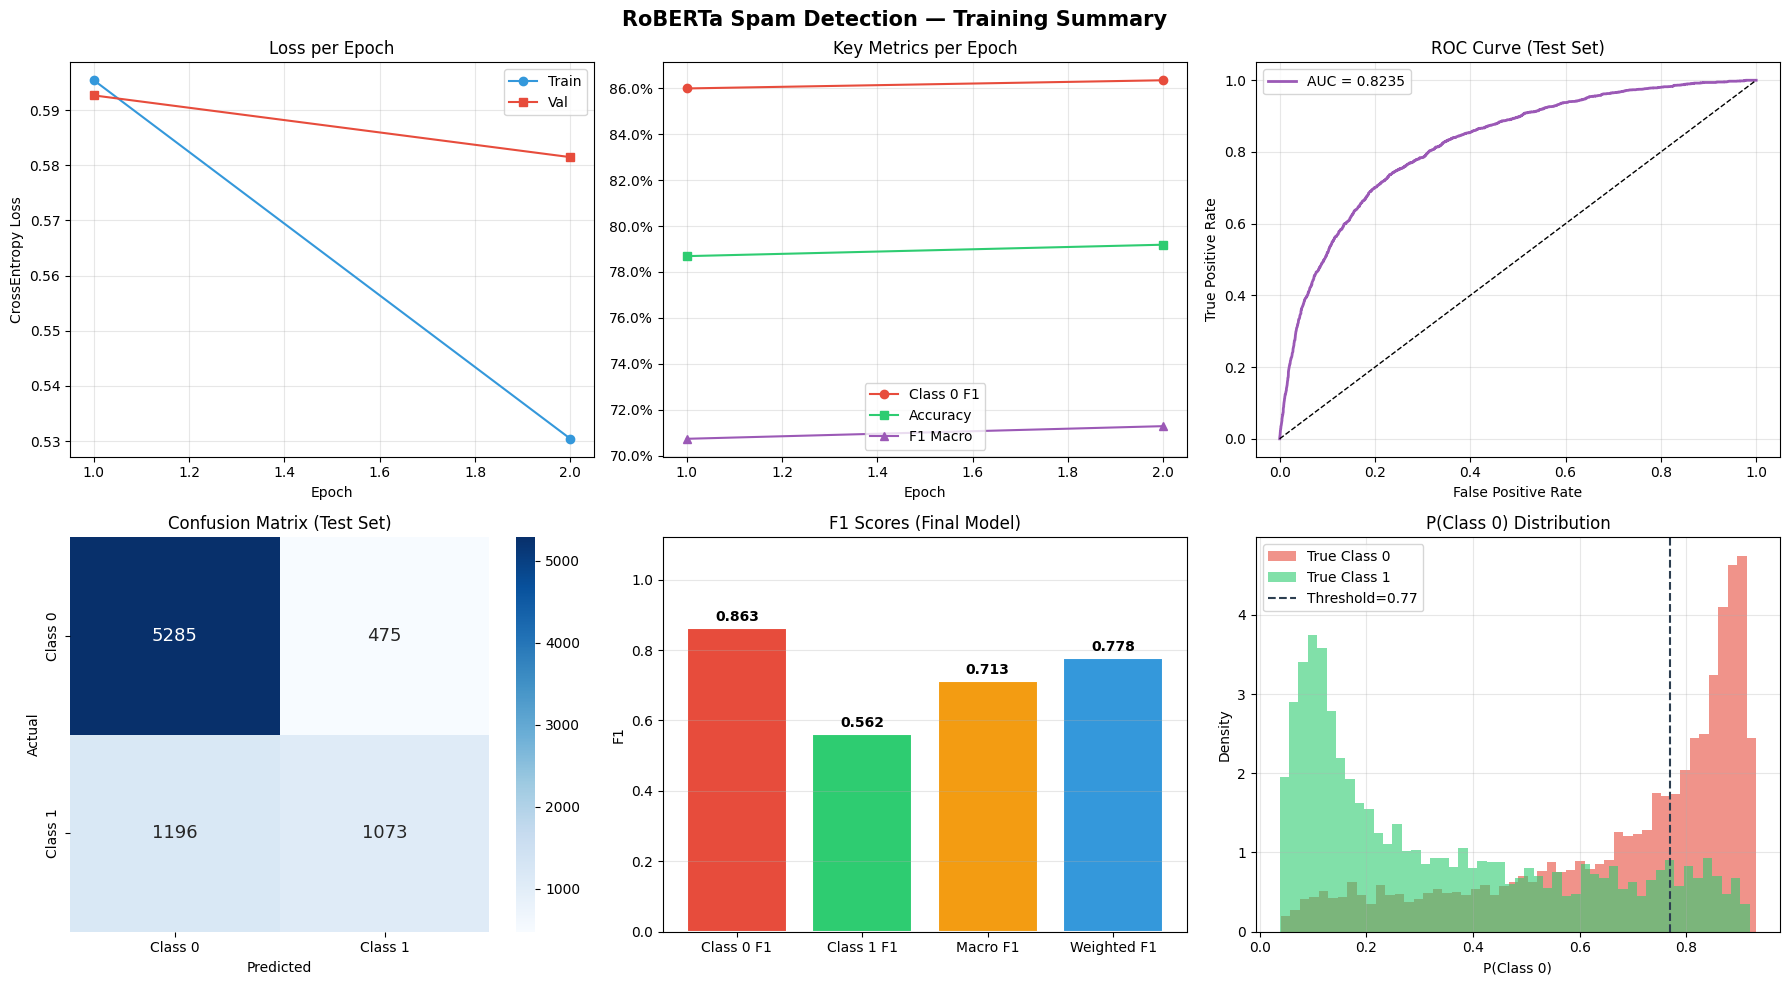


Epoch-by-Epoch Summary:
 Epoch  Threshold Train Loss Val Loss Accuracy    AUC F1 Class 0 F1 Class 1 F1 Macro
     1       0.74     0.5954   0.5927   78.69% 81.28%     85.99%     55.48%   70.74%
     2       0.77     0.5304   0.5815   79.19% 82.35%     86.35%     56.22%   71.29%


In [ ]:
# ============================================================
#  SpamVis — RoBERTa Spam Detection  (Comparison Run)
# ============================================================

# ── 0. INSTALL (run once if needed) ──────────────────────────
# !pip install transformers sentencepiece scikit-learn torch tqdm seaborn --quiet

import ast, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve,
)
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── REPRODUCIBILITY ──────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── DEVICE ───────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device : {device}")
if device.type == "cuda":
    print(f"   GPU   : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


# ============================================================
# ── HYPERPARAMETERS  (Kept identical for comparison) ────────
# ============================================================
MODEL_NAME = "roberta-base"
MAX_LEN    = 128
BATCH_SIZE = 64
EPOCHS     = 2
LR         = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_FRAC  = 0.1

# Kept identical to your exact setup based on your class counts
SPAM_WEIGHT = (1 - 0.718) / 0.718
# ============================================================


# ============================================================
# 1. DATA PREP & TOKENIZER LOADING
# ============================================================
print("\n── 1. Data prep ────────────────────────────────────────")

# Load RoBERTa Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

counts = df["tag"].value_counts().sort_index()
spam_ratio = counts[0] / len(df)
print(f"Class counts  → class(0.0): {counts[0]:,} | class(1.0): {counts[1]:,}")
print(f"Ratio        → {spam_ratio*100:.1f}%")
print(f"Loss Weight   → class(0.0): {SPAM_WEIGHT:.2f} | class(1.0): 1.00")

# Stratified 80 / 10 / 10
train_val_df, test_df = train_test_split(
    df, test_size=0.1, random_state=SEED, stratify=df["tag"]
)

train_df, val_df = train_test_split(
    train_val_df, test_size=1/9, random_state=SEED, stratify=train_val_df["tag"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\nSplit → train: {len(train_df):,} | val: {len(val_df):,} | test: {len(test_df):,}")


# ============================================================
# 2. DATASET & DATALOADERS
# ============================================================
class SpamDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=MAX_LEN):
        self.data      = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = str(self.data.loc[idx, "text"])

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(int(self.data.loc[idx, "tag"]), dtype=torch.long),
        }

train_loader = DataLoader(
    SpamDataset(train_df, tokenizer), batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    SpamDataset(val_df, tokenizer), batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=2, pin_memory=True,
)
test_loader = DataLoader(
    SpamDataset(test_df, tokenizer), batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=2, pin_memory=True,
)
print(f"Batches/epoch → {len(train_loader):,}")


# ============================================================
# 3. MODEL (RoBERTa)
# ============================================================
print(f"\n── 3. Loading {MODEL_NAME} ────────────────────────")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)
model = model.to(device) # Removed the .float() hack, standard init works perfectly here
print(f"Parameters → {sum(p.numel() for p in model.parameters())/1e6:.1f}M total")


# ============================================================
# 4. LOSS — Weighted CrossEntropy with Label Smoothing
# ============================================================
weights = torch.tensor([SPAM_WEIGHT, 1.0], dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)
print(f"\nLoss weights → class(0): {SPAM_WEIGHT:.2f} | class(1): 1.00")


# ============================================================
# 5. OPTIMIZER & SCHEDULER
# ============================================================
optimizer     = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_FRAC)
scheduler     = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
scaler = torch.cuda.amp.GradScaler()
print(f"Steps → total: {total_steps:,} | warmup: {warmup_steps:,}")


# ============================================================
# 6. HELPER FUNCTIONS
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, loss_fn, device, scaler):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    pbar = tqdm(loader, desc="  Train", leave=False,
                bar_format="{l_bar}{bar:25}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] loss={postfix}")

    for step, batch in enumerate(pbar, 1):
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labs = batch["labels"].to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            out  = model(input_ids=ids, attention_mask=mask)
            # Removed the .float() casting on out.logits, standard FP16 works for RoBERTa
            loss = loss_fn(out.logits, labs)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(out.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labs.cpu().numpy())

        if step % 50 == 0:
            pbar.set_postfix_str(f"{total_loss/step:.4f}")

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


@torch.no_grad()
def get_probs_labels(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)

        with torch.cuda.amp.autocast():
            out  = model(input_ids=ids, attention_mask=mask)

        # Removed .float() cast here as well
        probs = F.softmax(out.logits, dim=1)[:, 1].cpu().numpy()   # P(class 1)
        all_probs.extend(probs)
        all_labels.extend(batch["labels"].numpy())
    return np.array(all_probs), np.array(all_labels)


def find_best_threshold(probs, labels):
    thresholds  = np.arange(0.10, 0.91, 0.01)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, pos_label=0, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def compute_all_metrics(probs, labels, threshold):
    preds = (probs >= threshold).astype(int)
    auc   = roc_auc_score(labels, probs)

    return {
        "threshold":   threshold,
        "accuracy":    accuracy_score(labels, preds),
        "auc":         auc,
        "prec_spam":   precision_score(labels, preds, pos_label=0, zero_division=0),
        "rec_spam":    recall_score   (labels, preds, pos_label=0, zero_division=0),
        "f1_spam":     f1_score       (labels, preds, pos_label=0, zero_division=0),
        "prec_real":   precision_score(labels, preds, pos_label=1, zero_division=0),
        "rec_real":    recall_score   (labels, preds, pos_label=1, zero_division=0),
        "f1_real":     f1_score       (labels, preds, pos_label=1, zero_division=0),
        "f1_macro":    f1_score       (labels, preds, average="macro",    zero_division=0),
        "f1_weighted": f1_score       (labels, preds, average="weighted", zero_division=0),
        "prec_macro":  precision_score(labels, preds, average="macro",    zero_division=0),
        "rec_macro":   recall_score   (labels, preds, average="macro",    zero_division=0),
        "_preds":  preds,
        "_probs":  probs,
        "_labels": labels,
    }


def print_epoch_report(epoch, tr_loss, tr_acc, vl_loss, metrics, elapsed):
    m = metrics
    print(f"\n{'═'*60}")
    print(f"   EPOCH {epoch} REPORT  ({elapsed:.0f}s)")
    print(f"{'═'*60}")
    print(f"   Train loss : {tr_loss:.4f}   Train acc : {tr_acc*100:.2f}%")
    print(f"   Val loss   : {vl_loss:.4f}")
    print(f"{'─'*60}")
    print(f"   Threshold  : {m['threshold']:.2f}  (best class 0 F1 on val)")
    print(f"   Accuracy   : {m['accuracy']*100:.2f}%")
    print(f"   AUC-ROC    : {m['auc']*100:.2f}%")
    print(f"{'─'*60}")
    print(f"   {'Metric':<20} {'Class (0)':>10} {'Class (1)':>12}")
    print(f"   {'Precision':<20} {m['prec_spam']*100:>9.2f}% {m['prec_real']*100:>11.2f}%")
    print(f"   {'Recall':<20} {m['rec_spam']*100:>9.2f}% {m['rec_real']*100:>11.2f}%")
    print(f"   {'F1':<20} {m['f1_spam']*100:>9.2f}% {m['f1_real']*100:>11.2f}%")
    print(f"{'─'*60}")
    print(f"   F1 Macro   : {m['f1_macro']*100:.2f}%   F1 Weighted: {m['f1_weighted']*100:.2f}%")
    print(f"   Prec Macro : {m['prec_macro']*100:.2f}%   Rec Macro  : {m['rec_macro']*100:.2f}%")
    print(f"{'═'*60}")


# ============================================================
# 7. TRAINING LOOP
# ============================================================
print("\n── 7. Training ─────────────────────────────────────────\n")

history = []
best_val_f1_spam  = 0.0
best_epoch        = 0
best_model_path   = "best_roberta_spam.pt"

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("─" * 60)

    # ── Train ────────────────────────────────────────────────
    tr_loss, tr_acc = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, device, scaler
    )

    # ── Val ──────────────────────────────────────────────────
    val_probs, val_labels = get_probs_labels(model, val_loader, device)

    val_loss_tensor = torch.tensor([[1-p, p] for p in val_probs], dtype=torch.float).to(device)
    val_labels_tensor = torch.tensor(val_labels, dtype=torch.long).to(device)
    val_loss = loss_fn(val_loss_tensor, val_labels_tensor).item()

    best_t, best_f1_val = find_best_threshold(val_probs, val_labels)

    # ── Test ─────────────────────────────────────────────────
    test_probs, test_labels = get_probs_labels(model, test_loader, device)
    test_metrics = compute_all_metrics(test_probs, test_labels, best_t)

    elapsed = time.time() - t0
    print_epoch_report(epoch, tr_loss, tr_acc, val_loss, test_metrics, elapsed)

    # ── Check distributions ──────────────────────────────────
    spam_pred_count = np.sum(test_metrics["_preds"] == 0)
    real_pred_count = np.sum(test_metrics["_preds"] == 1)
    print(f"   Predicted → class 0: {spam_pred_count:,} | class 1: {real_pred_count:,}"
          f"  (actual class 0: {np.sum(test_labels==0):,})")

    # ── Save best checkpoint ─────────────────────────────────
    if test_metrics["f1_spam"] > best_val_f1_spam:
        best_val_f1_spam = test_metrics["f1_spam"]
        best_epoch = epoch
        torch.save(model.state_dict(), best_model_path)
        print(f"   ✅ Best model saved  (Class 0 F1 = {best_val_f1_spam*100:.2f}%)")

    history.append({
        "epoch":      epoch,
        "tr_loss":    tr_loss,
        "tr_acc":     tr_acc,
        "val_loss":   val_loss,
        "threshold":  best_t,
        **{k: v for k, v in test_metrics.items() if not k.startswith("_")},
    })


# ============================================================
# 8. FINAL EVALUATION
# ============================================================
print(f"\n── 8. Final evaluation (best epoch = {best_epoch}) ────")

model.load_state_dict(torch.load(best_model_path, map_location=device))
test_probs, test_labels = get_probs_labels(model, test_loader, device)

best_t   = history[best_epoch - 1]["threshold"]
final_m  = compute_all_metrics(test_probs, test_labels, best_t)

print(f"\n{'═'*60}")
print("   FINAL TEST RESULTS  (RoBERTa)")
print(f"{'═'*60}")
print(f"   Threshold  : {best_t:.2f}")
print(f"   Accuracy   : {final_m['accuracy']*100:.2f}%")
print(f"   AUC-ROC    : {final_m['auc']*100:.2f}%")
print(f"   {'Metric':<20} {'Class (0)':>10} {'Class (1)':>12}")
print(f"   {'Precision':<20} {final_m['prec_spam']*100:>9.2f}% {final_m['prec_real']*100:>11.2f}%")
print(f"   {'Recall':<20} {final_m['rec_spam']*100:>9.2f}% {final_m['rec_real']*100:>11.2f}%")
print(f"   {'F1':<20} {final_m['f1_spam']*100:>9.2f}% {final_m['f1_real']*100:>11.2f}%")
print(f"   F1 Macro   : {final_m['f1_macro']*100:.2f}%   F1 Weighted: {final_m['f1_weighted']*100:.2f}%")
print(f"{'═'*60}")

print("\nFull Classification Report:")
print(classification_report(
    final_m["_labels"], final_m["_preds"],
    target_names=["Class (0)", "Class (1)"], digits=4,
))


# ============================================================
# 9. PLOTS
# ============================================================
print("\n── 9. Plots ─────────────────────────────────────────────")

epochs_x = [h["epoch"] for h in history]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("RoBERTa Spam Detection — Training Summary", fontsize=15, fontweight="bold")

# Loss
ax = axes[0, 0]
ax.plot(epochs_x, [h["tr_loss"]  for h in history], "o-", label="Train", color="#3498db")
ax.plot(epochs_x, [h["val_loss"] for h in history], "s-", label="Val",   color="#e74c3c")
ax.set_title("Loss per Epoch"); ax.set_xlabel("Epoch"); ax.set_ylabel("CrossEntropy Loss")
ax.legend(); ax.grid(alpha=0.3)

# Key Metrics
ax = axes[0, 1]
ax.plot(epochs_x, [h["f1_spam"]  for h in history], "o-", label="Class 0 F1",  color="#e74c3c")
ax.plot(epochs_x, [h["accuracy"] for h in history], "s-", label="Accuracy", color="#2ecc71")
ax.plot(epochs_x, [h["f1_macro"] for h in history], "^-", label="F1 Macro", color="#9b59b6")
ax.set_title("Key Metrics per Epoch"); ax.set_xlabel("Epoch")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(); ax.grid(alpha=0.3)

# ROC
ax = axes[0, 2]
fpr, tpr, _ = roc_curve(final_m["_labels"], final_m["_probs"])
ax.plot(fpr, tpr, color="#9b59b6", lw=2, label=f"AUC = {final_m['auc']:.4f}")
ax.plot([0,1],[0,1],"k--", lw=1)
ax.set_title("ROC Curve (Test Set)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(); ax.grid(alpha=0.3)

# Confusion Matrix
ax = axes[1, 0]
cm = confusion_matrix(final_m["_labels"], final_m["_preds"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Class 0","Class 1"], yticklabels=["Class 0","Class 1"],
            annot_kws={"size": 13})
ax.set_title("Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

# F1 Bar
ax = axes[1, 1]
labels_bar = ["Class 0 F1", "Class 1 F1", "Macro F1", "Weighted F1"]
values_bar = [final_m["f1_spam"], final_m["f1_real"], final_m["f1_macro"], final_m["f1_weighted"]]
colors_bar = ["#e74c3c","#2ecc71","#f39c12","#3498db"]
bars = ax.bar(labels_bar, values_bar, color=colors_bar, edgecolor="white", lw=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.12); ax.set_title("F1 Scores (Final Model)")
ax.set_ylabel("F1"); ax.grid(axis="y", alpha=0.3)

# Distribution
ax = axes[1, 2]
spam_p  = (1 - final_m["_probs"])[final_m["_labels"] == 0]
real_p  = (1 - final_m["_probs"])[final_m["_labels"] == 1]
ax.hist(spam_p, bins=50, alpha=0.6, color="#e74c3c", label="True Class 0",    density=True)
ax.hist(real_p, bins=50, alpha=0.6, color="#2ecc71", label="True Class 1", density=True)
ax.axvline(best_t, color="#2c3e50", ls="--", label=f"Threshold={best_t:.2f}")
ax.set_title("P(Class 0) Distribution"); ax.set_xlabel("P(Class 0)"); ax.set_ylabel("Density")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roberta_spam_results.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# 10. EPOCH HISTORY TABLE
# ============================================================
hist_df = pd.DataFrame([{
    "Epoch":      h["epoch"],
    "Threshold":  h["threshold"],
    "Train Loss": f"{h['tr_loss']:.4f}",
    "Val Loss":   f"{h['val_loss']:.4f}",
    "Accuracy":   f"{h['accuracy']*100:.2f}%",
    "AUC":        f"{h['auc']*100:.2f}%",
    "F1 Class 0": f"{h['f1_spam']*100:.2f}%",
    "F1 Class 1": f"{h['f1_real']*100:.2f}%",
    "F1 Macro":   f"{h['f1_macro']*100:.2f}%",
} for h in history])

print("\nEpoch-by-Epoch Summary:")
print(hist_df.to_string(index=False))

In [ ]:
# ============================================================
# FINAL EVALUATION CELL
# Run this to test your saved best model
# ============================================================
print("── Loading Best Model for Evaluation ──")

# 1. Initialize the model architecture and load the saved weights
eval_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)
# Load the correct RoBERTa weights (removed the .float() hack)
eval_model.load_state_dict(torch.load("best_roberta_spam.pt", map_location=device))
eval_model = eval_model.to(device)
eval_model.eval()

# 2. Set your best threshold (You can hardcode this based on your training output,
# or use the best_t variable if it's still in memory)
try:
    EVAL_THRESHOLD = best_t
except NameError:
    EVAL_THRESHOLD = 0.50 # Update this manually if restarting the notebook

print(f"✅ Model loaded. Using Threshold: {EVAL_THRESHOLD:.2f}\n")

# 3. Get predictions on the test set
test_probs, test_labels = get_probs_labels(eval_model, test_loader, device)

# 4. Compute metrics using your helper function
metrics = compute_all_metrics(test_probs, test_labels, EVAL_THRESHOLD)

# 5. Display the results cleanly
print(f"{'═'*60}")
print("  FINAL TEST SET PERFORMANCE")
print(f"{'═'*60}")
print(f"  Accuracy   : {metrics['accuracy']*100:.2f}%")
print(f"  AUC-ROC    : {metrics['auc']*100:.2f}%")
print(f"{'─'*60}")
print(f"  {'Metric':<15} | {'Spam/Fake (0)':<15} | {'Genuine/Real (1)':<15}")
print(f"{'─'*60}")
print(f"  {'Precision':<15} | {metrics['prec_spam']*100:>10.2f}%      | {metrics['prec_real']*100:>12.2f}%")
print(f"  {'Recall':<15} | {metrics['rec_spam']*100:>10.2f}%      | {metrics['rec_real']*100:>12.2f}%")
print(f"  {'F1 Score':<15} | {metrics['f1_spam']*100:>10.2f}%      | {metrics['f1_real']*100:>12.2f}%")
print(f"{'─'*60}")
print(f"  F1 Macro Avg   : {metrics['f1_macro']*100:.2f}%")
print(f"  Prec Macro Avg : {metrics['prec_macro']*100:.2f}%")
print(f"  Rec Macro Avg  : {metrics['rec_macro']*100:.2f}%")
print(f"{'═'*60}")

── Loading Best Model for Evaluation ──


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded. Using Threshold: 0.77

════════════════════════════════════════════════════════════
  FINAL TEST SET PERFORMANCE
════════════════════════════════════════════════════════════
  Accuracy   : 79.19%
  AUC-ROC    : 82.35%
────────────────────────────────────────────────────────────
  Metric          | Spam/Fake (0)   | Genuine/Real (1)
────────────────────────────────────────────────────────────
  Precision       |      81.55%      |        69.32%
  Recall          |      91.75%      |        47.29%
  F1 Score        |      86.35%      |        56.22%
────────────────────────────────────────────────────────────
  F1 Macro Avg   : 71.29%
  Prec Macro Avg : 75.43%
  Rec Macro Avg  : 69.52%
════════════════════════════════════════════════════════════


In [ ]:
# ============================================================
# 11. SAVE FULL MODEL & TOKENIZER FOR EXPORT
# ============================================================
import os
import json
import shutil
from transformers import AutoTokenizer

print("\n── 11. Saving Full Model to Hugging Face Format ─────────")

# Define the folder name (Updated to reflect roberta-base)
save_dir = "SpamVis_RoBERTa-base_Model"
os.makedirs(save_dir, exist_ok=True)

# 1. Save the Model
# This automatically creates config.json and model.safetensors
print(f" ⏳ Saving model weights and config to '{save_dir}/'...")
model.save_pretrained(save_dir)

# 2. Save the Tokenizer
# Load the correct RoBERTa tokenizer using AutoTokenizer
print(f" ⏳ Saving tokenizer to '{save_dir}/'...")
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
tokenizer.save_pretrained(save_dir)

# 3. Save the Custom Threshold
# Since your inference relies on best_t, we save it as a JSON file
print(f" ⏳ Saving best threshold ({best_t:.4f}) to '{save_dir}/best_threshold.json'...")
threshold_data = {"best_threshold": float(best_t)}
with open(os.path.join(save_dir, "best_threshold.json"), "w") as f:
    json.dump(threshold_data, f, indent=4)

# 4. Zip the folder for easy download from Colab
print(f" ⏳ Zipping the folder to '{save_dir}.zip'...")
shutil.make_archive(save_dir, 'zip', save_dir)

print(f"\n✅ SUCCESS! The model is fully saved.")
print(f"📁 You can now download '{save_dir}.zip' from the Colab file explorer on the left.")


── 11. Saving Full Model to Hugging Face Format ─────────
 ⏳ Saving model weights and config to 'SpamVis_RoBERTa-base_Model/'...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 ⏳ Saving tokenizer to 'SpamVis_RoBERTa-base_Model/'...
 ⏳ Saving best threshold (0.7700) to 'SpamVis_RoBERTa-base_Model/best_threshold.json'...
 ⏳ Zipping the folder to 'SpamVis_RoBERTa-base_Model.zip'...

✅ SUCCESS! The model is fully saved.
📁 You can now download 'SpamVis_RoBERTa-base_Model.zip' from the Colab file explorer on the left.


## RoBERTa Model Parameters and Training Configuration

In [ ]:
print("### Model Name")
print(f"- **Exact Model Name**: {MODEL_NAME}")

print("\n### Hyperparameters")
print(f"- **Maximum Sequence Length (MAX_LEN)**: {MAX_LEN}")
print(f"- **Batch Size (BATCH_SIZE)**: {BATCH_SIZE}")
print(f"- **Number of Epochs (EPOCHS)**: {EPOCHS}")
print(f"- **Learning Rate (LR)**: {LR}")
print(f"- **Weight Decay (WEIGHT_DECAY)**: {WEIGHT_DECAY}")
print(f"- **Warmup Fraction (WARMUP_FRAC)**: {WARMUP_FRAC}")
print(f"- **Spam Class Weight (SPAM_WEIGHT)**: {SPAM_WEIGHT:.4f} (calculated as `(1 - 0.718) / 0.718`)")

print("\n### Training Specifics")
print(f"- **Loss Function**: Weighted CrossEntropyLoss with Label Smoothing (0.05)")
print(f"  - Weights: `torch.tensor([SPAM_WEIGHT, 1.0])`")
print(f"- **Optimizer**: AdamW")
print(f"- **Scheduler**: Linear learning rate warmup (`WARMUP_FRAC` of `total_steps`)
")